# 03_churn_prediction.ipynb
## Step 1: Import Libraries and Load Prepared RFM Data
In this notebook, we build machine learning models using `scikit-learn` to predict customer churn based on RFM scores and customer behavioral features.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Load the RFM customer dataset created in Notebook 02
df = pd.read_csv('rfm_customer_data.csv') # Update filename if needed
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2236, 10)


,ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,Customer_Segment
0,5524,58,25,1617,2,4,4,244,10,Champions
1,2174,38,6,27,3,1,1,311,5,At Risk
2,4141,26,21,776,3,3,3,333,9,Loyal Customers
3,6182,26,8,53,3,1,1,311,5,At Risk
4,5324,94,19,422,1,3,3,133,7,Promising / Potential


In [10]:
# Create Churn Label: 1 if customer belongs to 'At Risk' or 'Lost / Inactive', else 0
df['Is_Churn'] = df['Customer_Segment'].apply(lambda x: 1 if x in ['At Risk', 'Lost / Inactive'] else 0)

# Select features for machine learning
X = df[['Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score']]
y = df['Is_Churn']

print("Churn Distribution:")
print(y.value_counts(normalize=True))

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Churn Distribution:
Is_Churn
0    0.756708
1    0.243292
Name: proportion, dtype: float64


In [11]:
# 1. Logistic Regression Model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# 2. Random Forest Classifier Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       339
           1       1.00      0.99      1.00       109

    accuracy                           1.00       448
   macro avg       1.00      1.00      1.00       448
weighted avg       1.00      1.00      1.00       448

ROC AUC Score (Random Forest): 1.0


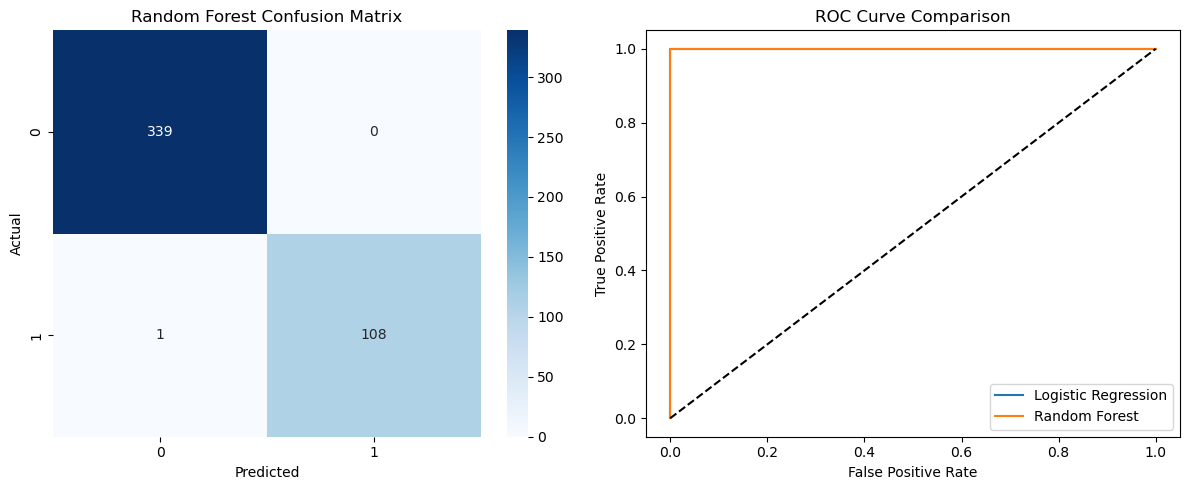

In [12]:
# Evaluate Random Forest Model
print("=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf))

print("ROC AUC Score (Random Forest):", round(roc_auc_score(y_test, y_prob_rf), 4))

# Plot Confusion Matrix
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Random Forest Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# ROC Curve comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

ax[1].plot(fpr_lr, tpr_lr, label='Logistic Regression')
ax[1].plot(fpr_rf, tpr_rf, label='Random Forest')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title('ROC Curve Comparison')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].legend()

plt.tight_layout()
plt.show()

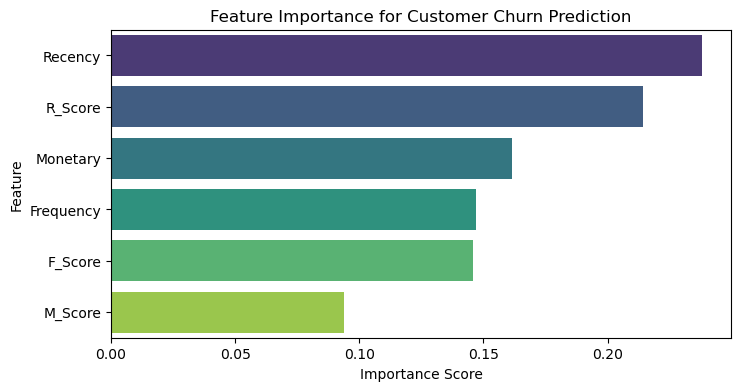

In [14]:
# Feature Importance for Random Forest
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
# Updated sns.barplot line to resolve the warning:
sns.barplot(x=feature_importances.values, y=feature_importances.index, hue=feature_importances.index, palette='viridis', legend=False)
plt.title('Feature Importance for Customer Churn Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()